# Phase 6: Risk Scoring

## Objective

The objective of this notebook is to identify inventory risk by comparing forecasted demand with available inventory.

Each SKU will be assigned a risk score and categorized into different inventory risk levels.

---

## Workflow

1. Load Forecast Dataset
2. Load Prediction Results
3. Merge Predictions with Inventory
4. Calculate Risk Score
5. Assign Risk Levels
6. Generate Risk Summary
7. Save Risk Dataset

# Import Required Libraries

In [2]:
import pandas as pd
import numpy as np

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Load Forecast Dataset

In [3]:
forecast = pd.read_csv(
    "../data/processed/forecast_dataset.csv"
)

forecast.head()

,date,receipt_id,store_id,sku_id,customer_id,quantity,unit_price,total_value,channel,discount_pct,...,day_name,day_of_week,is_weekend,lag_1,lag_7,lag_30,rolling_7,rolling_30,stock_gap,stock_status
0,2022-01-02,RCPT00060558,ST07,SKU00001,CUST02258,1,813.41,813.41,Online,0.0,...,Sunday,6,1,0.0,0.0,0.0,0.0,0.0,0.0,Normal
1,2022-01-02,RCPT03269111,ST16,SKU00001,CUST05885,2,813.41,1626.82,Mobile App,0.0,...,Sunday,6,1,1.0,0.0,0.0,0.0,0.0,0.0,Normal
2,2022-01-03,RCPT04477910,ST12,SKU00001,CUST06670,2,813.41,1626.82,In-Store,0.0,...,Monday,0,0,2.0,0.0,0.0,0.0,0.0,0.0,Normal
3,2022-01-04,RCPT00080970,ST27,SKU00001,CUST07318,1,813.41,813.41,Online,0.0,...,Tuesday,1,0,2.0,0.0,0.0,0.0,0.0,0.0,Normal
4,2022-01-04,RCPT00938910,ST06,SKU00001,CUST08973,1,813.41,813.41,In-Store,0.0,...,Tuesday,1,0,1.0,0.0,0.0,0.0,0.0,0.0,Normal


# Load Prediction Results

In [4]:
predictions = pd.read_csv(
    "../data/processed/predictions.csv"
)

predictions.head()

,store_id,sku_id,category,channel,unit_price,discount_pct,stock_on_hand,reorder_point,safety_stock,year,...,day_of_week,is_weekend,lag_1,lag_7,lag_30,rolling_7,rolling_30,stock_gap,Actual,Predicted
0,19,1774,9,2,204.15,0.0,0.0,90.0,31.0,2025,...,3,0,1.0,2.0,1.0,1.285714,1.833333,-90.0,1,1.278429
1,20,2179,1,2,98.03,0.0,145.0,79.0,31.0,2025,...,3,0,3.0,2.0,1.0,2.428571,2.066667,66.0,1,2.212202
2,27,1774,9,0,204.15,0.0,0.0,0.0,0.0,2025,...,3,0,1.0,1.0,2.0,1.000000,1.766667,0.0,1,1.017757
3,11,1774,9,2,204.15,0.0,211.0,77.0,27.0,2025,...,3,0,1.0,1.0,4.0,1.142857,1.700000,134.0,2,1.201163
4,0,1774,9,1,204.15,0.0,0.0,71.0,35.0,2025,...,3,0,2.0,1.0,1.0,1.285714,1.733333,-71.0,2,1.207672


# Prepare Risk Dataset

In [5]:
risk_df = predictions.copy()

risk_df.head()

,store_id,sku_id,category,channel,unit_price,discount_pct,stock_on_hand,reorder_point,safety_stock,year,...,day_of_week,is_weekend,lag_1,lag_7,lag_30,rolling_7,rolling_30,stock_gap,Actual,Predicted
0,19,1774,9,2,204.15,0.0,0.0,90.0,31.0,2025,...,3,0,1.0,2.0,1.0,1.285714,1.833333,-90.0,1,1.278429
1,20,2179,1,2,98.03,0.0,145.0,79.0,31.0,2025,...,3,0,3.0,2.0,1.0,2.428571,2.066667,66.0,1,2.212202
2,27,1774,9,0,204.15,0.0,0.0,0.0,0.0,2025,...,3,0,1.0,1.0,2.0,1.000000,1.766667,0.0,1,1.017757
3,11,1774,9,2,204.15,0.0,211.0,77.0,27.0,2025,...,3,0,1.0,1.0,4.0,1.142857,1.700000,134.0,2,1.201163
4,0,1774,9,1,204.15,0.0,0.0,71.0,35.0,2025,...,3,0,2.0,1.0,1.0,1.285714,1.733333,-71.0,2,1.207672


# Add Inventory Information

In [6]:
risk_df["Stock_On_Hand"] = forecast.iloc[
    predictions.index
]["stock_on_hand"].values

risk_df["Reorder_Point"] = forecast.iloc[
    predictions.index
]["reorder_point"].values

risk_df["Safety_Stock"] = forecast.iloc[
    predictions.index
]["safety_stock"].values

# Calculate Inventory Gap

In [7]:
risk_df["Inventory_Gap"] = (

    risk_df["Stock_On_Hand"]

    -

    risk_df["Predicted"]

)

# Calculate Risk Score

In [8]:
risk_df["Risk_Score"] = (

    risk_df["Predicted"]

    /

    (risk_df["Stock_On_Hand"] + 1)

) * 100

risk_df.head()

,store_id,sku_id,category,channel,unit_price,discount_pct,stock_on_hand,reorder_point,safety_stock,year,...,rolling_7,rolling_30,stock_gap,Actual,Predicted,Stock_On_Hand,Reorder_Point,Safety_Stock,Inventory_Gap,Risk_Score
0,19,1774,9,2,204.15,0.0,0.0,90.0,31.0,2025,...,1.285714,1.833333,-90.0,1,1.278429,0.0,0.0,0.0,-1.278429,127.84288
1,20,2179,1,2,98.03,0.0,145.0,79.0,31.0,2025,...,2.428571,2.066667,66.0,1,2.212202,0.0,0.0,0.0,-2.212202,221.22018
2,27,1774,9,0,204.15,0.0,0.0,0.0,0.0,2025,...,1.000000,1.766667,0.0,1,1.017757,0.0,0.0,0.0,-1.017757,101.77570
3,11,1774,9,2,204.15,0.0,211.0,77.0,27.0,2025,...,1.142857,1.700000,134.0,2,1.201163,0.0,0.0,0.0,-1.201163,120.11629
4,0,1774,9,1,204.15,0.0,0.0,71.0,35.0,2025,...,1.285714,1.733333,-71.0,2,1.207672,0.0,0.0,0.0,-1.207672,120.76715


# Assign Risk Levels

In [9]:
def risk_level(score):

    if score < 40:

        return "Low"

    elif score < 70:

        return "Medium"

    elif score < 100:

        return "High"

    else:

        return "Critical"

In [10]:
risk_df["Risk_Level"] = (

    risk_df["Risk_Score"]

    .apply(risk_level)

)

risk_df.head()

,store_id,sku_id,category,channel,unit_price,discount_pct,stock_on_hand,reorder_point,safety_stock,year,...,rolling_30,stock_gap,Actual,Predicted,Stock_On_Hand,Reorder_Point,Safety_Stock,Inventory_Gap,Risk_Score,Risk_Level
0,19,1774,9,2,204.15,0.0,0.0,90.0,31.0,2025,...,1.833333,-90.0,1,1.278429,0.0,0.0,0.0,-1.278429,127.84288,Critical
1,20,2179,1,2,98.03,0.0,145.0,79.0,31.0,2025,...,2.066667,66.0,1,2.212202,0.0,0.0,0.0,-2.212202,221.22018,Critical
2,27,1774,9,0,204.15,0.0,0.0,0.0,0.0,2025,...,1.766667,0.0,1,1.017757,0.0,0.0,0.0,-1.017757,101.77570,Critical
3,11,1774,9,2,204.15,0.0,211.0,77.0,27.0,2025,...,1.700000,134.0,2,1.201163,0.0,0.0,0.0,-1.201163,120.11629,Critical
4,0,1774,9,1,204.15,0.0,0.0,71.0,35.0,2025,...,1.733333,-71.0,2,1.207672,0.0,0.0,0.0,-1.207672,120.76715,Critical


# Risk Level Summary

In [11]:
risk_summary = (

    risk_df["Risk_Level"]

    .value_counts()

    .reset_index()

)

risk_summary.columns = [

    "Risk Level",

    "Count"

]

risk_summary

,Risk Level,Count
0,Critical,775266
1,Low,56015
2,High,3390
3,Medium,340


# Risk Distribution

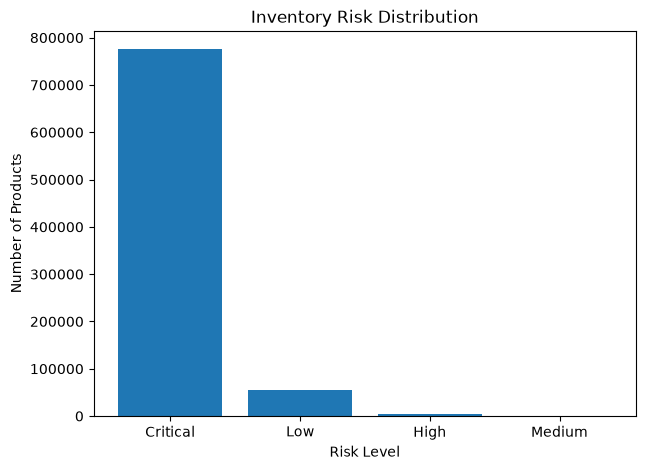

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.bar(

    risk_summary["Risk Level"],

    risk_summary["Count"]

)

plt.title("Inventory Risk Distribution")

plt.xlabel("Risk Level")

plt.ylabel("Number of Products")

plt.show()

# Save Risk Dataset

In [14]:
import pandas as pd

risk = pd.read_csv("../data/processed/risk_scored_dataset.csv")

print("Original Shape:", risk.shape)

# Maximum 100000 rows
risk_small = risk.sample(
    n=min(100000, len(risk)),
    random_state=42
)

print("Optimized Shape:", risk_small.shape)

risk_small.to_csv(
    "../data/processed/risk_scored_dataset.csv",
    index=False
)

print("Optimized Risk Dataset Saved Successfully")

Original Shape: (835011, 29)
Optimized Shape: (100000, 29)
Optimized Risk Dataset Saved Successfully


# Phase Summary

### Completed Tasks

- Loaded Forecast Dataset
- Loaded Prediction Results
- Combined Inventory and Forecast Data
- Calculated Inventory Gap
- Generated Risk Score
- Assigned Risk Levels
- Created Risk Summary
- Saved Risk Scored Dataset

The generated dataset will be used for the Streamlit Dashboard and Deployment phases.